# Introduction
This notebook tries to mimic the operation condition.
One should control the position of the motors and optics through the manipulation of the corresponding motion axes through the pre-defined functions.
In this way, one moves within the range permitted by the motor and respect the geometric constrain of the installation of the setup.

Initially, I thought I could move the installation operation to this notebook.
However, it seems that that is not very possible simply due to the complexity of the module.

#### Definition
1. um, fs, keV
2. normal is pointing inwards the reflection surface
3. The coordinate convention of this simulation and its relation to XPP coordinate is 
    (axis 0, axis 1, axis 2) = (vertical, horizontal, propagation) = (xpp y, xpp x, xpp z)
    i.e., The name in this code is x,y,z, using one convension. In the text, use the XPP convention 

np.fft(field) = spectrum

np.ifft(spectrum) = field

# Step 1: Ray Tracing Calculation

In [1]:
import time
import sys
sys.path.append("../../../../XRaySimulation")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches

# Level 1 dependence
from XRaySimulation import Pulse, DeviceSimu, util

# Level 2 dependece
import parser
import Controller

plt.rcParams.update({'font.size': 14})

In [2]:
# Create the experiment setup
exp = Controller.XppController_TG()

Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, ro

# Define functions on the fly

# Preparation: Align the mono

Motor moved from 0.00000 to -17.88927 degree
Motor moved from 0.00000 to -17.88927 degree
Motor moved from -17.88927 to -17.89070 degree
Motor moved from -17.88927 to -17.89076 degree


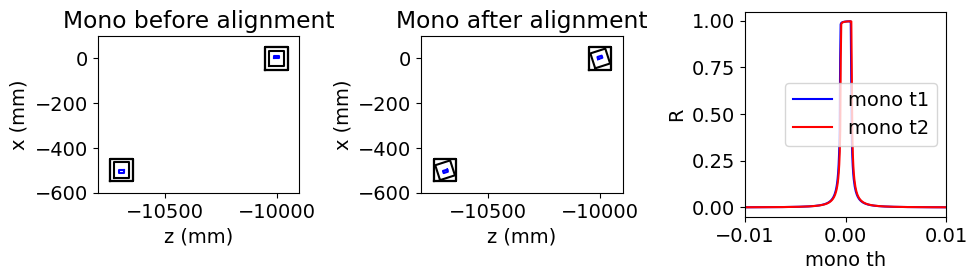

In [3]:
# Prepare a canvas. This section is not important. 
fig, ax = plt.subplots(ncols=3, nrows=1)
fig.set_figheight(3)
fig.set_figwidth(10)

exp.plot_motors(ax=ax[0], color='black')
exp.plot_optics(ax=ax[0], color='blue')

ax[0].set_aspect('equal')
ax[0].set_title("Mono before alignment")
ax[0].set_xlabel("z (mm)")
ax[0].set_ylabel("x (mm)")
ax[0].set_xlim([-10e3 - 800, -10e3 + 100])
ax[0].set_ylim([- 600, 100])

_ = exp.align_xpp_mono()
exp.plot_motors(ax=ax[1], color='black')
exp.plot_optics(ax=ax[1], color='blue')

ax[1].set_aspect('equal')
ax[1].set_title("Mono after alignment")
ax[1].set_xlabel("z (mm)")
ax[1].set_ylabel("x (mm)")
ax[1].set_xlim([-10e3 - 800, -10e3 + 100])
ax[1].set_ylim([- 600, 100])

ax[2].plot(np.rad2deg(exp.mono_t1_rocking[0]), exp.mono_t1_rocking[1], c='b', label='mono t1')
ax[2].plot(np.rad2deg(exp.mono_t2_rocking[0]), exp.mono_t1_rocking[1], c='r', label='mono t2')
ax[2].set_xlim([-0.01, 0.01])
ax[2].set_xlabel("mono th")
ax[2].set_ylabel("R")
ax[2].legend()

plt.tight_layout()
plt.show()

# Preparation: Align the miniSD

Motor moved from 0.00000 to 19.23525 degree
Motor moved from 0.00000 to -19.23525 degree
Motor moved from 0.00000 to 19.23525 degree
Motor moved from 0.00000 to 19.23525 degree
Motor moved from 0.00000 to -19.23525 degree
Motor moved from 0.00000 to -19.23525 degree
Motor moved from 19.23525 to 19.23620 degree
Motor moved from -19.23525 to -19.23605 degree
Motor moved from -19.23525 to -19.23601 degree
Motor moved from 19.23525 to 19.23716 degree
Motor moved from 19.23525 to 19.23702 degree
Motor moved from -19.23525 to -19.23591 degree


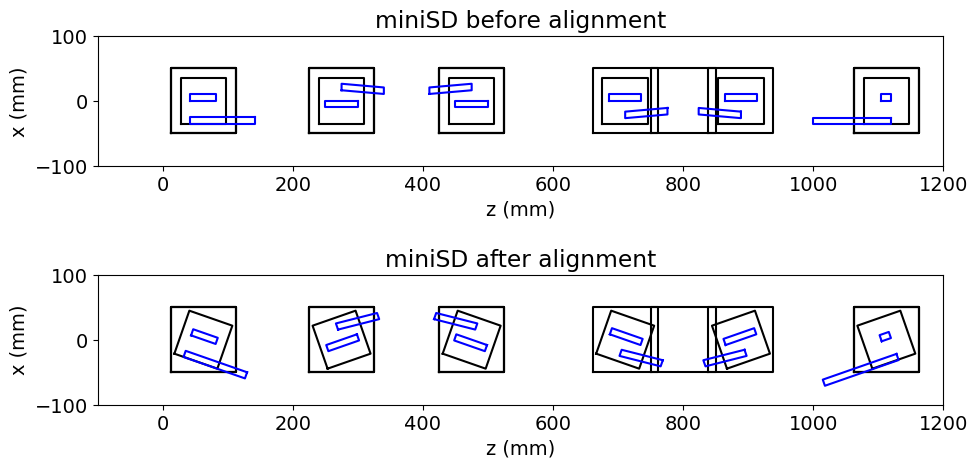

In [4]:
# Prepare a canvas. This section is not important. 
fig, ax = plt.subplots(ncols=1, nrows=2)
fig.set_figheight(5)
fig.set_figwidth(10)

# -----------------------------------------------
#     Before alignment
# -----------------------------------------------
exp.plot_motors(ax=ax[0], color='black')
exp.plot_optics(ax=ax[0], color='blue')
ax[0].set_aspect('equal')
ax[0].set_title("miniSD before alignment")
ax[0].set_xlabel("z (mm)")
ax[0].set_ylabel("x (mm)")
ax[0].set_xlim([-100, 1200])
ax[0].set_ylim([-100, 100])

# -----------------------------------------------
#     After alignment
# -----------------------------------------------
_ = exp.align_miniSD()

exp.plot_motors(ax=ax[1], color='black')
exp.plot_optics(ax=ax[1], color='blue')

ax[1].set_aspect('equal')
ax[1].set_title("miniSD after alignment")
ax[1].set_xlabel("z (mm)")
ax[1].set_ylabel("x (mm)")
ax[1].set_xlim([-100, 1200])
ax[1].set_ylim([-100, 100])

plt.tight_layout()
plt.show()

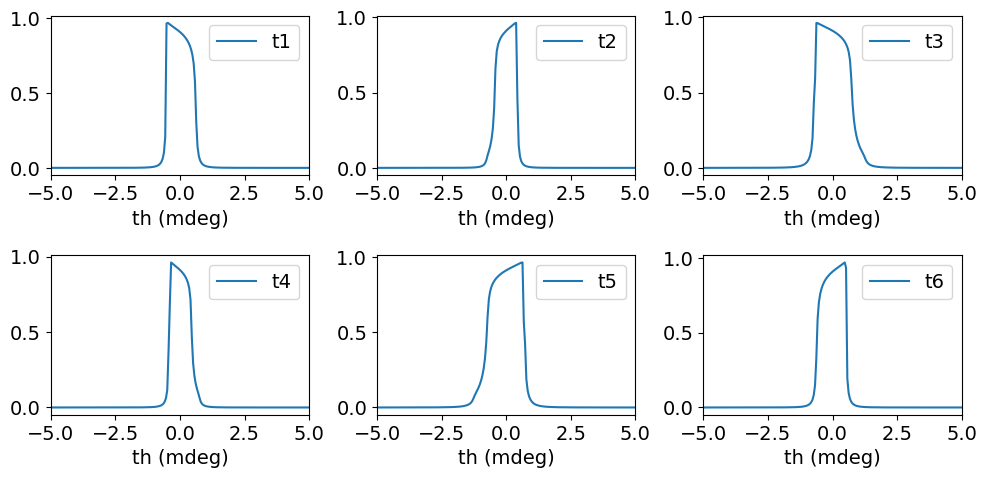

In [5]:
fig, ax = plt.subplots(ncols=3, nrows=2)
fig.set_figheight(5)
fig.set_figwidth(10)

record_to_plot = [exp.t1_rocking, exp.t2_rocking, exp.t3_rocking, exp.t4_rocking, exp.t5_rocking, exp.t6_rocking]
for idx in range(2):
    for idx2 in range(3):
        record = record_to_plot[idx2 + idx * 3]
        ax[idx, idx2].plot(np.rad2deg(record[0]) * 1000, record[1], label='t{}'.format(idx2 + 3 * idx + 1))
        ax[idx, idx2].set_xlabel('th (mdeg)')
        ax[idx, idx2].legend()
        ax[idx, idx2].set_xlim([-5, 5])
plt.tight_layout()
plt.show()

# Step 1: Find the X-ray pulse after miniSD on the downstream YAG after the miniSD

In [6]:
cc_traj, kout, cc_pathlength = exp.get_raytracing_trajectory(path="cc", get_path_length='True')
vcc_traj, kout, vcc_pathlength = exp.get_raytracing_trajectory(path="vcc", get_path_length='True')

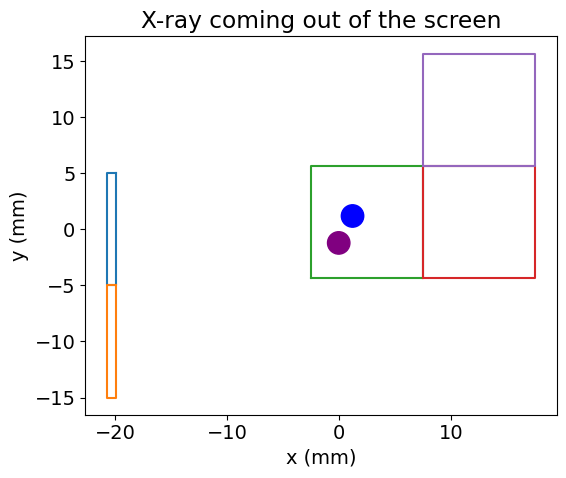

In [7]:
# Show the YAG boundaries and the CC pulse location on the YAG
fig, ax = plt.subplots(ncols=1, nrows=1)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.sample.all_optics:
    ax.plot(item.boundary[:,1]/1000, item.boundary[:,0]/1000,)
cc_spot = patches.Circle((cc_traj[-1][1] / 1e3, cc_traj[-1][0]/1e3), radius=1, color='blue')
vcc_spot = patches.Circle((vcc_traj[-1][1]/1e3, vcc_traj[-1][0]/1e3), radius=1, color='purple')
ax.add_patch(cc_spot)
ax.add_patch(vcc_spot)

ax.set_aspect('equal')
ax.set_title("X-ray coming out of the screen")
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")

plt.tight_layout()
plt.show()

# Step 2: Align the probe beam such that it overlap with the CC beam
## Step 2a: Find the beam after the mirror 1 on the YAG


In [8]:
# Assume that we have calibrated the incident angle
_ = exp.m1.pi_umv(np.deg2rad(0.1))

# Move the mirror position such that the interaction point with the mirror is at location z=4e6
path_ref = exp.get_raytracing_trajectory(path="probe m1 only")
_ = exp.m1.y_umvr(100)
path_new = exp.get_raytracing_trajectory(path="probe m1 only")

coef = path_new[0][-2][2] - path_ref[0][-2][2]
total_diff = exp.m1.optics.surface_point[2] - path_new[0][-2][2]
print("Move the TG-a pulse {:.5f} um in y axis by moving m1y 100 um".format(coef))
print("Need to move m1y {:.5f} um to compensate the total difference of {:.5f} um".format(
    total_diff / coef * 100, total_diff))
_ = exp.m1.y_umvr(total_diff / coef * 100)

Motor moved from 0.00000 to 0.10000 degree
Motor moved from 0.0000 um to to 100.0000 um
Move the TG-a pulse -53365.38310 um in y axis by moving m1y 100 um
Need to move m1y -850.42800 um to compensate the total difference of 453834.16026 um
Motor moved from 100.0000 um to to -750.4280 um


In [9]:
probe_m1_traj, kout, probe_m1_pathlength = exp.get_raytracing_trajectory(path="probe m1 only", get_path_length='True')

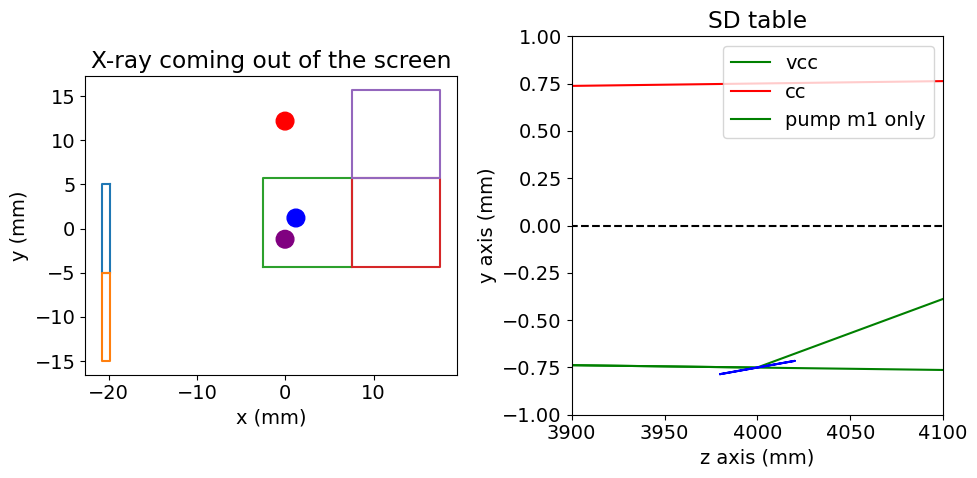

In [10]:
# Show the YAG boundaries and the CC pulse location on the YAG
fig, ax = plt.subplots(ncols=2, nrows=1)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.sample.all_optics:
    ax[0].plot(item.boundary[:,1]/1000, item.boundary[:,0]/1000,)
cc_spot = patches.Circle((cc_traj[-1][1] / 1e3, cc_traj[-1][0]/1e3), radius=1, color='blue')
vcc_spot = patches.Circle((vcc_traj[-1][1]/1e3, vcc_traj[-1][0]/1e3), radius=1, color='purple')
probe_m1_spot = patches.Circle((probe_m1_traj[-1][1]/1e3, probe_m1_traj[-1][0]/1e3), radius=1, color='red')
ax[0].add_patch(cc_spot)
ax[0].add_patch(vcc_spot)
ax[0].add_patch(probe_m1_spot)

ax[0].set_aspect('equal')
ax[0].set_title("X-ray coming out of the screen")
ax[0].set_xlabel("x (mm)")
ax[0].set_ylabel("y (mm)")

ax[1].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
ax[1].plot(vcc_traj[:,2] / 1e3, vcc_traj[:,0] / 1e3, 'g', label='vcc')
ax[1].plot(cc_traj[:,2] / 1e3, cc_traj[:,0] / 1e3, 'r', label='cc')
ax[1].plot(probe_m1_traj[:,2] / 1e3, probe_m1_traj[:,0] / 1e3, color='g', label='pump m1 only')
exp.plot_optics(ax=ax[1], axis='yz', color='blue')

ax[1].set_ylim([-1, 1])
ax[1].set_xlim([3900, 4100])
ax[1].set_xlabel("z axis (mm)")
ax[1].set_ylabel("y axis (mm)")
ax[1].set_title('SD table')
ax[1].legend()

plt.tight_layout()
plt.show()

## Step 2b Align the silicon 111 crystal

In [11]:
probe_old_traj, kout, probe_old_pathlength= exp.get_raytracing_trajectory(path="probe")

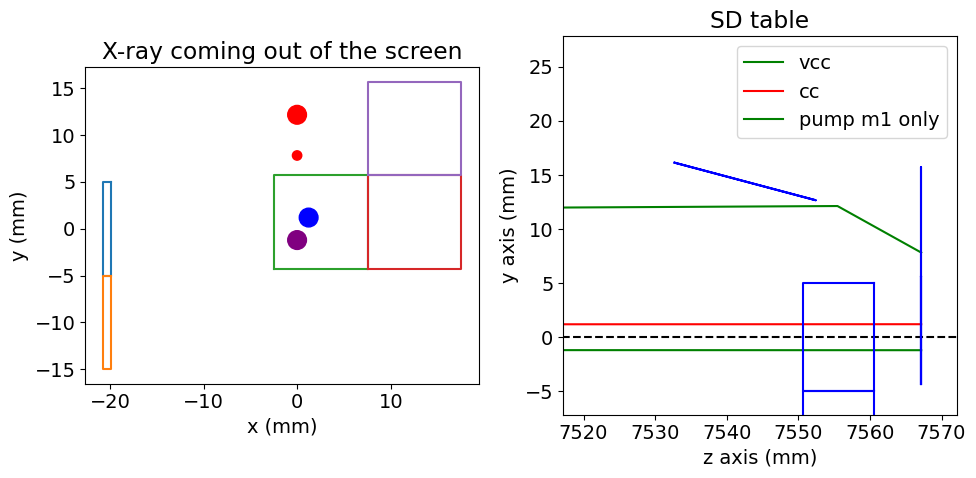

In [12]:
# Show the YAG boundaries and the CC pulse location on the YAG
fig, ax = plt.subplots(ncols=2, nrows=1)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.sample.all_optics:
    ax[0].plot(item.boundary[:,1]/1000, item.boundary[:,0]/1000,)
cc_spot = patches.Circle((cc_traj[-1][1] / 1e3, cc_traj[-1][0]/1e3), radius=1, color='blue')
vcc_spot = patches.Circle((vcc_traj[-1][1]/1e3, vcc_traj[-1][0]/1e3), radius=1, color='purple')
probe_m1_spot = patches.Circle((probe_m1_traj[-1][1]/1e3, probe_m1_traj[-1][0]/1e3), radius=1, color='red')
probe_old_spot = patches.Circle((probe_old_traj[-1][1]/1e3, probe_old_traj[-1][0]/1e3), radius=0.5, color='red')
ax[0].add_patch(cc_spot)
ax[0].add_patch(vcc_spot)
ax[0].add_patch(probe_m1_spot)
ax[0].add_patch(probe_old_spot)

ax[0].set_aspect('equal')
ax[0].set_title("X-ray coming out of the screen")
ax[0].set_xlabel("x (mm)")
ax[0].set_ylabel("y (mm)")

ax[1].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
ax[1].plot(vcc_traj[:,2] / 1e3, vcc_traj[:,0] / 1e3, 'g', label='vcc')
ax[1].plot(cc_traj[:,2] / 1e3, cc_traj[:,0] / 1e3, 'r', label='cc')
ax[1].plot(probe_old_traj[:,2] / 1e3, probe_old_traj[:,0] / 1e3, color='g', label='pump m1 only')
exp.plot_optics(ax=ax[1], axis='yz', color='blue')

ax[1].set_ylim([probe_old_traj[-1,0] / 1e3 - 15, probe_old_traj[-1,0] / 1e3 + 20])
ax[1].set_xlim([probe_old_traj[-1,2] / 1e3 - 50, probe_old_traj[-1,2] / 1e3 + 5])
ax[1].set_xlabel("z axis (mm)")
ax[1].set_ylabel("y axis (mm)")
ax[1].set_title('SD table')
ax[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# During operation, we need to make sure first that the X-ray is hiting on the si 111 crsytal
# Get the theoretical Bragg angle
bragg_si111 = util.get_bragg_angle(wave_length=np.pi * 2 / exp.gaussian_pulse.klen0, plane_distance=Controller.si111['d'])

# Account for the 10 deg of the adaptor tilting
ang_diff = bragg_si111 - np.deg2rad(10)

# Rotate the crystal by the remaining angle
_ = exp.si.pi_umv(ang_diff)

# Get the rocking curve from this crystal
(angles1, reflect_sigma1,
 reflect_pi1, b_factor1, kout1) = DeviceSimu.get_rocking_curve_around_axis(
                                kin=exp.gaussian_pulse.k0,
                                scan_range=np.deg2rad(0.5),
                                scan_number=10 ** 4,
                                rotation_axis=exp.si.pi.rotation_axis,
                                h_initial=exp.si.optics.h,
                                normal_initial=exp.si.optics.normal,
                                thickness=exp.si.optics.thickness,
                                chi_dict=exp.si.optics.chi_dict, )

# Get the target bragg peak
fwhm, angle_adjust, index = util.get_fwhm(coordinate=angles1,
                                          curve_values=np.square(np.abs(reflect_pi1)),
                                          center=True,
                                          get_index=True)

# Move the crystal to the target path
_ = exp.si.pi_umv(target= exp.si.pi.control_location + angle_adjust)

Motor moved from 0.00000 to 1.63904 degree
Motor moved from 1.63904 to 1.63959 degree


In [14]:
probe_old_traj, kout, probe_old_pathlength= exp.get_raytracing_trajectory(path="probe")

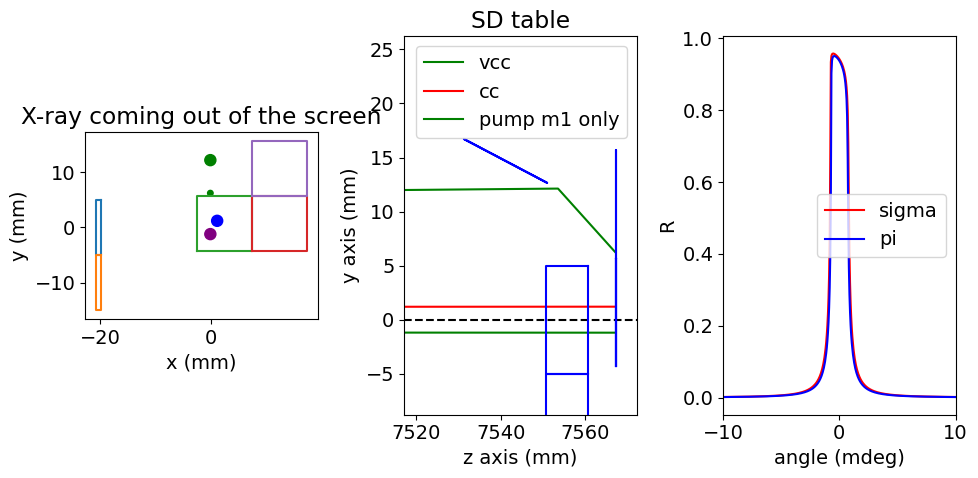

In [15]:
# Show the YAG boundaries and the CC pulse location on the YAG
fig, ax = plt.subplots(ncols=3, nrows=1)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.sample.all_optics:
    ax[0].plot(item.boundary[:,1]/1000, item.boundary[:,0]/1000,)
cc_spot = patches.Circle((cc_traj[-1][1] / 1e3, cc_traj[-1][0]/1e3), radius=1, color='blue')
vcc_spot = patches.Circle((vcc_traj[-1][1]/1e3, vcc_traj[-1][0]/1e3), radius=1, color='purple')
probe_m1_spot = patches.Circle((probe_m1_traj[-1][1]/1e3, probe_m1_traj[-1][0]/1e3), radius=1, color='green')
probe_old_spot = patches.Circle((probe_old_traj[-1][1]/1e3, probe_old_traj[-1][0]/1e3), radius=0.5, color='green')
ax[0].add_patch(cc_spot)
ax[0].add_patch(vcc_spot)
ax[0].add_patch(probe_m1_spot)
ax[0].add_patch(probe_old_spot)

ax[0].set_aspect('equal')
ax[0].set_title("X-ray coming out of the screen")
ax[0].set_xlabel("x (mm)")
ax[0].set_ylabel("y (mm)")

ax[1].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
ax[1].plot(vcc_traj[:,2] / 1e3, vcc_traj[:,0] / 1e3, 'g', label='vcc')
ax[1].plot(cc_traj[:,2] / 1e3, cc_traj[:,0] / 1e3, 'r', label='cc')
ax[1].plot(probe_old_traj[:,2] / 1e3, probe_old_traj[:,0] / 1e3, color='g', label='pump m1 only')
exp.plot_optics(ax=ax[1], axis='yz', color='blue')

ax[1].set_ylim([probe_old_traj[-1,0] / 1e3 - 15, probe_old_traj[-1,0] / 1e3 + 20])
ax[1].set_xlim([probe_old_traj[-1,2] / 1e3 - 50, probe_old_traj[-1,2] / 1e3 + 5])
ax[1].set_xlabel("z axis (mm)")
ax[1].set_ylabel("y axis (mm)")
ax[1].set_title('SD table')
ax[1].legend()

ax[2].plot(np.rad2deg(angles1 - angle_adjust) * 1000, np.square(np.abs(reflect_sigma1)), c='red', label='sigma')
ax[2].plot(np.rad2deg(angles1 - angle_adjust) * 1000, np.square(np.abs(reflect_pi1)), c='blue', label='pi')
ax[2].set_xlim([-10,10])
ax[2].set_xlabel("angle (mdeg)")
ax[2].set_ylabel("R")
ax[2].legend()

plt.tight_layout()
plt.show()

In [16]:
# Align the vertical overlap with the reference pump pulse
probe_old_traj, kout, probe_old_path = exp.get_raytracing_trajectory(path="probe")
_ = exp.si.y_umvr(100)
probe_new_traj, kout, probe_new_path = exp.get_raytracing_trajectory(path="probe")
pump_ref_traj, kout, pump_ref_path = exp.get_raytracing_trajectory(path="cc")

coef = probe_new_traj[-1][0] - probe_old_traj[-1][0]
total_diff = pump_ref_traj[-1][0] - probe_new_traj[-1][0]

print("Move the probe pulse {:.5f} um in y axis by moving siy 100 um".format(coef))
print("Need to move siy {:.5f} um to compensate the total difference of {:.5f} um".format(total_diff / coef * 100, total_diff))
_ = exp.si.y_umvr(total_diff / coef * 100)

# Move the si111 crystal along the x axis
x_offset = probe_new_traj[-1][1] - exp.si.optics.surface_point[1]
exp.si.x_umvr(x_offset)

Motor moved from 0.0000 um to to 100.0000 um
Move the probe pulse 209.06933 um in y axis by moving siy 100 um
Need to move siy -2494.83605 um to compensate the total difference of -5215.93690 um
Motor moved from 100.0000 um to to -2394.8361 um
Motor moved from 0.0000 um to to -34.5840 um


In [17]:
probe_traj, kout, probe_pathlength= exp.get_raytracing_trajectory(path="probe")

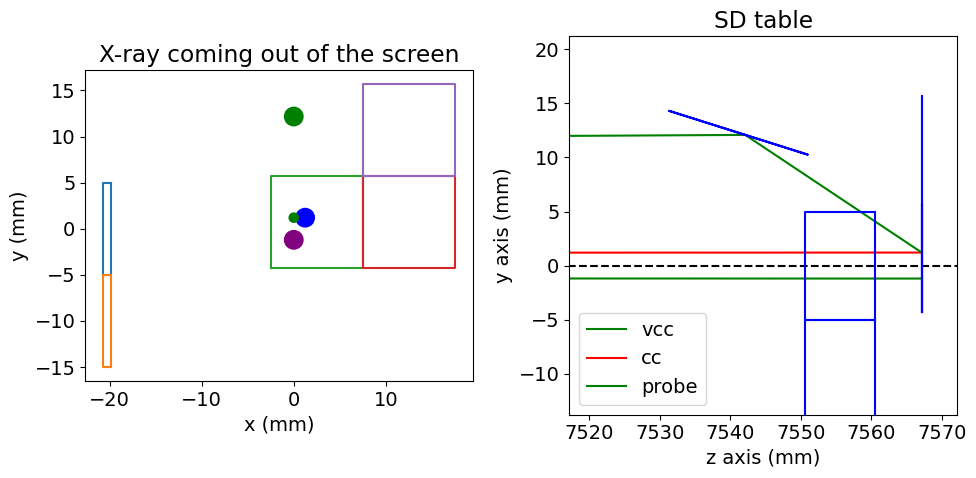

In [18]:
# Show the YAG boundaries and the CC pulse location on the YAG
fig, ax = plt.subplots(ncols=2, nrows=1)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.sample.all_optics:
    ax[0].plot(item.boundary[:,1]/1000, item.boundary[:,0]/1000,)
cc_spot = patches.Circle((cc_traj[-1][1] / 1e3, cc_traj[-1][0]/1e3), radius=1, color='blue')
vcc_spot = patches.Circle((vcc_traj[-1][1]/1e3, vcc_traj[-1][0]/1e3), radius=1, color='purple')
probe_m1_spot = patches.Circle((probe_m1_traj[-1][1]/1e3, probe_m1_traj[-1][0]/1e3), radius=1, color='green')
probe_traj_spot = patches.Circle((probe_traj[-1][1]/1e3, probe_traj[-1][0]/1e3), radius=0.5, color='green')
ax[0].add_patch(cc_spot)
ax[0].add_patch(vcc_spot)
ax[0].add_patch(probe_m1_spot)
ax[0].add_patch(probe_traj_spot)

ax[0].set_aspect('equal')
ax[0].set_title("X-ray coming out of the screen")
ax[0].set_xlabel("x (mm)")
ax[0].set_ylabel("y (mm)")

ax[1].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
ax[1].plot(vcc_traj[:,2] / 1e3, vcc_traj[:,0] / 1e3, 'g', label='vcc')
ax[1].plot(cc_traj[:,2] / 1e3, cc_traj[:,0] / 1e3, 'r', label='cc')
ax[1].plot(probe_traj[:,2] / 1e3, probe_traj[:,0] / 1e3, color='g', label='probe')
exp.plot_optics(ax=ax[1], axis='yz', color='blue')

ax[1].set_ylim([probe_traj[-1,0] / 1e3 - 15, probe_traj[-1,0] / 1e3 + 20])
ax[1].set_xlim([probe_traj[-1,2] / 1e3 - 50, probe_traj[-1,2] / 1e3 + 5])
ax[1].set_xlabel("z axis (mm)")
ax[1].set_ylabel("y axis (mm)")
ax[1].set_title('SD table')
ax[1].legend()

plt.tight_layout()
plt.show()

# Step 3: Align the total reflection mirrors for the pump pulse

In [19]:
_ = exp.m2a.yaw_umv(np.deg2rad(0.3))
_ = exp.m2a.x_umv(-9.5e3)

_ = exp.m2b.yaw_umv(np.deg2rad(-0.3))
_ = exp.m2b.x_umv(9966.5113)

Motor moved from 0.00000 to 0.30000 degree
Motor moved from 0.0000 um to to -9500.0000 um
Motor moved from 0.00000 to -0.30000 degree
Motor moved from 0.0000 um to to 9966.5113 um


In [20]:
probe_traj, kout, probe_pathlength= exp.get_raytracing_trajectory(path="probe")

pump_a_no_mirror_traj, kout, pump_a_path = exp.get_raytracing_trajectory(path='pump a no mirror')
pump_a_traj, kout, pump_a_path = exp.get_raytracing_trajectory(path='pump a')
pump_b_no_mirror_traj, kout, pump_a_path = exp.get_raytracing_trajectory(path='pump b no mirror')
pump_b_traj, kout, pump_a_path = exp.get_raytracing_trajectory(path='pump b')

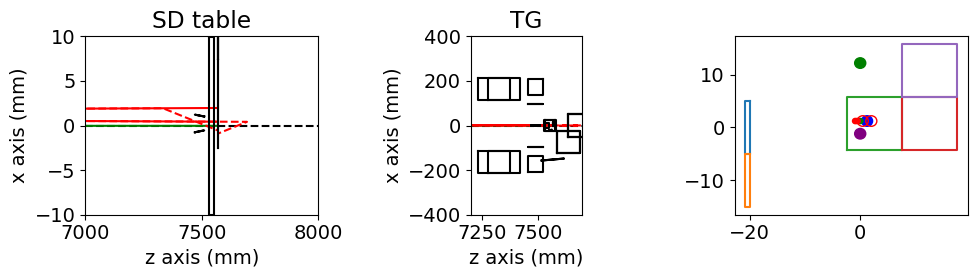

In [21]:
fig, axes = plt.subplots(ncols=3, nrows=1)

fig.set_figheight(3)
fig.set_figwidth(10)

axes[0].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
axes[0].plot(probe_traj[:,2] / 1e3, probe_traj[:,1] / 1e3, 'g', label='probe')
axes[0].plot(pump_a_no_mirror_traj[:,2] / 1e3, pump_a_no_mirror_traj[:,1] / 1e3, color='r', label='pump a no mirror')
axes[0].plot(pump_a_traj[:,2] / 1e3, pump_a_traj[:,1] / 1e3, linestyle='--', color='red', label='pump a')
axes[0].plot(pump_b_no_mirror_traj[:,2] / 1e3, pump_b_no_mirror_traj[:,1] / 1e3, color='r', label='pump b no mirror')
axes[0].plot(pump_b_traj[:,2] / 1e3, pump_b_traj[:,1] / 1e3, linestyle='--', color='red', label='pump b')
#exp.plot_motors(ax=axes[0])
exp.plot_optics(ax=axes[0])

axes[0].set_ylim([-10, 10])
axes[0].set_xlim([7000, 8000])
axes[0].set_xlabel("z axis (mm)")
axes[0].set_ylabel("x axis (mm)")
axes[0].set_title('SD table')


axes[1].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
axes[1].plot(probe_traj[:,2] / 1e3, probe_traj[:,1] / 1e3, 'g', label='probe')
axes[1].plot(pump_a_no_mirror_traj[:,2] / 1e3, pump_a_no_mirror_traj[:,1] / 1e3, color='r', label='pump a no mirror')
axes[1].plot(pump_a_traj[:,2] / 1e3, pump_a_traj[:,1] / 1e3, linestyle='--', color='red', label='pump a')
axes[1].plot(pump_b_no_mirror_traj[:,2] / 1e3, pump_b_no_mirror_traj[:,1] / 1e3, color='r', label='pump b no mirror')
axes[1].plot(pump_b_traj[:,2] / 1e3, pump_b_traj[:,1] / 1e3, linestyle='--', color='red', label='pump b')
exp.plot_motors(ax=axes[1])
exp.plot_optics(ax=axes[1])

axes[1].set_aspect("equal")
axes[1].set_ylim([-400, 400])
axes[1].set_xlim([7200, 7700])
axes[1].set_xlabel("z axis (mm)")
axes[1].set_ylabel("x axis (mm)")
axes[1].set_title('TG')


for item in exp.sample.all_optics:
    axes[2].plot(item.boundary[:,1]/1000, item.boundary[:,0]/1000,)
cc_spot = patches.Circle((cc_traj[-1][1] / 1e3, cc_traj[-1][0]/1e3), radius=1, color='blue')
vcc_spot = patches.Circle((vcc_traj[-1][1]/1e3, vcc_traj[-1][0]/1e3), radius=1, color='purple')
probe_m1_spot = patches.Circle((probe_m1_traj[-1][1]/1e3, probe_m1_traj[-1][0]/1e3), radius=1, color='green')
probe_traj_spot = patches.Circle((probe_traj[-1][1]/1e3, probe_traj[-1][0]/1e3), radius=0.5, color='green')
pump_a_spot1 = patches.Circle((pump_a_no_mirror_traj[-1][1]/1e3, pump_a_no_mirror_traj[-1][0]/1e3), 
                              radius=1, fill=False, edgecolor='red')
pump_a_spot2 = patches.Circle((pump_a_traj[-1][1]/1e3, pump_a_traj[-1][0]/1e3), 
                              radius=0.5, facecolor='red', edgecolor='red')
pump_b_spot1 = patches.Circle((pump_b_no_mirror_traj[-1][1]/1e3, pump_b_no_mirror_traj[-1][0]/1e3), 
                              radius=1, fill=False, edgecolor='red')
pump_b_spot2 = patches.Circle((pump_b_traj[-1][1]/1e3, pump_b_traj[-1][0]/1e3), 
                              radius=0.5, facecolor='red', edgecolor='red')
axes[2].add_patch(cc_spot)
axes[2].add_patch(vcc_spot)
axes[2].add_patch(probe_m1_spot)
axes[2].add_patch(probe_traj_spot)
axes[2].add_patch(pump_a_spot1)
axes[2].add_patch(pump_a_spot2)
axes[2].add_patch(pump_b_spot1)
axes[2].add_patch(pump_b_spot2)
#axes[2].legend(loc=(0,-1.1))

plt.tight_layout()
plt.show()

In [47]:
print("Get trajectory a")
_ = exp.m2a.x_umvr(100)
pump_a_traj_new, kout, pump_a_path = exp.get_raytracing_trajectory(path='pump a')
# Get the ratio
coef = pump_a_traj_new[-1][1] - pump_a_traj[-1][1]
total_diff = probe_traj[-1][1] - pump_a_traj_new[-1][1]
print("Move the TG-a pulse {:.5f} um in x axis by moving m2a_x 100 um".format(coef))
print("Need to move m2a_x {:.5f} um to compensate the total difference of {:.5f} um".format(total_diff / coef * 100, 
                                                                                            total_diff))
_ = exp.m2a.x_umvr(total_diff / coef * 100)

print("\n ")

print("Get trajectory b")
_ = exp.m2b.x_umvr(100)
pump_b_traj_new, kout, pump_b_path = exp.get_raytracing_trajectory(path='pump b')
# Get the ratio
coef = pump_b_traj_new[-1][1] - pump_b_traj[-1][1]
total_diff = probe_traj[-1][1] - pump_b_traj_new[-1][1]
print("Move the TG-a pulse {:.5f} um in x axis by moving m2a_x 100 um".format(coef))
print("Need to move m2a_x {:.5f} um to compensate the total difference of {:.5f} um".format(total_diff / coef * 100, 
                                                                                            total_diff))
_ = exp.m2b.x_umvr(total_diff / coef * 100)

Get trajectory a
Motor moved from -8409.2363 um to to -8309.2363 um
Move the TG-a pulse 1434.08861 um in x axis by moving m2a_x 100 um
Need to move m2a_x -100.06676 um to compensate the total difference of -1435.04602 um
Motor moved from -8309.2363 um to to -8409.3031 um

 
Get trajectory b
Motor moved from 10807.7561 um to to 10907.7561 um
Move the TG-a pulse 1441.09731 um in x axis by moving m2a_x 100 um
Need to move m2a_x -100.12282 um to compensate the total difference of -1442.86733 um
Motor moved from 10907.7561 um to to 10807.6333 um


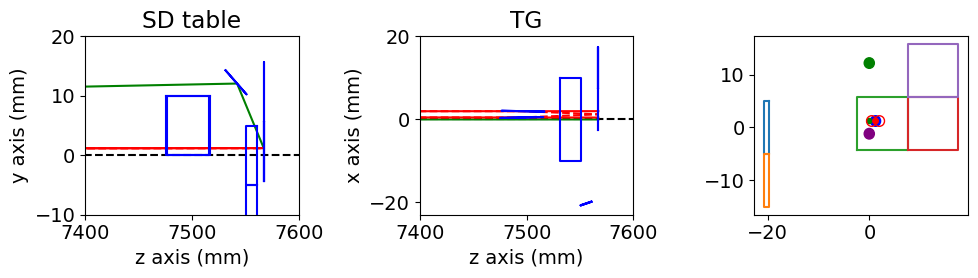

In [55]:
# Update the trajectory calculation
probe_traj, kout, probe_pathlength= exp.get_raytracing_trajectory(path="probe")
pump_a_no_mirror_traj, kout, pump_a_path = exp.get_raytracing_trajectory(path='pump a no mirror')
pump_a_traj, kout, pump_a_path = exp.get_raytracing_trajectory(path='pump a')
pump_b_no_mirror_traj, kout, pump_a_path = exp.get_raytracing_trajectory(path='pump b no mirror')
pump_b_traj, kout, pump_a_path = exp.get_raytracing_trajectory(path='pump b')

# ----------------------------------------------------------
fig, axes = plt.subplots(ncols=3, nrows=1)

fig.set_figheight(3)
fig.set_figwidth(10)

axes[0].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
axes[0].plot(probe_traj[:,2] / 1e3, probe_traj[:,0] / 1e3, 'g', label='probe')
axes[0].plot(pump_a_no_mirror_traj[:,2] / 1e3, pump_a_no_mirror_traj[:,0] / 1e3, color='r', label='pump a no mirror')
axes[0].plot(pump_a_traj[:,2] / 1e3, pump_a_traj[:,0] / 1e3, linestyle='--', color='red', label='pump a')
axes[0].plot(pump_b_no_mirror_traj[:,2] / 1e3, pump_b_no_mirror_traj[:,0] / 1e3, color='r', label='pump b no mirror')
axes[0].plot(pump_b_traj[:,2] / 1e3, pump_b_traj[:,0] / 1e3, linestyle='--', color='red', label='pump b')
#exp.plot_motors(ax=axes[0])
exp.plot_optics(ax=axes[0], axis='yz', color='blue')

axes[0].set_ylim([-10, 20])
axes[0].set_xlim([7400, 7600])
axes[0].set_xlabel("z axis (mm)")
axes[0].set_ylabel("y axis (mm)")
axes[0].set_title('SD table')


axes[1].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
axes[1].plot(probe_traj[:,2] / 1e3, probe_traj[:,1] / 1e3, 'g', label='probe')
axes[1].plot(pump_a_no_mirror_traj[:,2] / 1e3, pump_a_no_mirror_traj[:,1] / 1e3, color='r', label='pump a no mirror')
axes[1].plot(pump_a_traj[:,2] / 1e3, pump_a_traj[:,1] / 1e3, linestyle='--', color='red', label='pump a')
axes[1].plot(pump_b_no_mirror_traj[:,2] / 1e3, pump_b_no_mirror_traj[:,1] / 1e3, color='r', label='pump b no mirror')
axes[1].plot(pump_b_traj[:,2] / 1e3, pump_b_traj[:,1] / 1e3, linestyle='--', color='red', label='pump b')
exp.plot_optics(ax=axes[1], axis='xz', color='blue')
#axes[1].set_aspect("equal")
axes[1].set_ylim([-23, 20])
axes[1].set_xlim([7400, 7600])
axes[1].set_xlabel("z axis (mm)")
axes[1].set_ylabel("x axis (mm)")
axes[1].set_title('TG')


for item in exp.sample.all_optics:
    axes[2].plot(item.boundary[:,1]/1000, item.boundary[:,0]/1000,)
cc_spot = patches.Circle((cc_traj[-1][1] / 1e3, cc_traj[-1][0]/1e3), radius=1, color='blue')
vcc_spot = patches.Circle((vcc_traj[-1][1]/1e3, vcc_traj[-1][0]/1e3), radius=1, color='purple')
probe_m1_spot = patches.Circle((probe_m1_traj[-1][1]/1e3, probe_m1_traj[-1][0]/1e3), radius=1, color='green')
probe_traj_spot = patches.Circle((probe_traj[-1][1]/1e3, probe_traj[-1][0]/1e3), radius=0.5, color='green')
pump_a_spot1 = patches.Circle((pump_a_no_mirror_traj[-1][1]/1e3, pump_a_no_mirror_traj[-1][0]/1e3), 
                              radius=1, fill=False, edgecolor='red')
pump_a_spot2 = patches.Circle((pump_a_traj[-1][1]/1e3, pump_a_traj[-1][0]/1e3), 
                              radius=0.5, facecolor='red', edgecolor='red')
pump_b_spot1 = patches.Circle((pump_b_no_mirror_traj[-1][1]/1e3, pump_b_no_mirror_traj[-1][0]/1e3), 
                              radius=1, fill=False, edgecolor='red')
pump_b_spot2 = patches.Circle((pump_b_traj[-1][1]/1e3, pump_b_traj[-1][0]/1e3), 
                              radius=0.5, facecolor='red', edgecolor='red')
axes[2].add_patch(cc_spot)
axes[2].add_patch(vcc_spot)
axes[2].add_patch(probe_m1_spot)
axes[2].add_patch(probe_traj_spot)
axes[2].add_patch(pump_a_spot1)
axes[2].add_patch(pump_a_spot2)
axes[2].add_patch(pump_b_spot1)
axes[2].add_patch(pump_b_spot2)
#axes[2].legend(loc=(0,-1.1))

plt.tight_layout()
plt.show()